<a href="https://colab.research.google.com/github/Natalie31706-code/EEGseizuredetection/blob/main/EEG_seizure_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib scipy scikit-learn

In [ ]:
from google.colab import files
files.upload()  # Select the kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mahamahmoud66","key":"fb74587ec2ae1bbdd36b630216116f07"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle
import os

In [ ]:
!kaggle datasets download -d quands/eeg-dataset --force
!unzip -o eeg-dataset.zip
print(os.listdir("Dataset"))

Dataset URL: https://www.kaggle.com/datasets/quands/eeg-dataset
License(s): apache-2.0
100% 3.01M/3.01M [00:00<00:00, 87.0MB/s]

Archive:  eeg-dataset.zip
  inflating: Dataset/F/F001.txt      
  inflating: Dataset/F/F002.txt      
  inflating: Dataset/F/F003.txt      
  inflating: Dataset/F/F004.txt      
  inflating: Dataset/F/F005.txt      
  inflating: Dataset/F/F006.txt      
  inflating: Dataset/F/F007.txt      
  inflating: Dataset/F/F008.txt      
  inflating: Dataset/F/F009.txt      
  inflating: Dataset/F/F010.txt      
  inflating: Dataset/F/F011.txt      
  inflating: Dataset/F/F012.txt      
  inflating: Dataset/F/F013.txt      
  inflating: Dataset/F/F014.txt      
  inflating: Dataset/F/F015.txt      
  inflating: Dataset/F/F016.txt      
  inflating: Dataset/F/F017.txt      
  inflating: Dataset/F/F018.txt      
  inflating: Dataset/F/F019.txt      
  inflating: Dataset/F/F020.txt      
  inflating: Dataset/F/F021.txt      
  inflating: Dataset/F/F022.txt      
  inflati

In [ ]:
import numpy as np
import os

base = "Dataset"
folders = {
    "N": f"{base}/N",
    "O": f"{base}/O",
    "F": f"{base}/F",
    "S": f"{base}/S",
    "Z": f"{base}/Z"
}

data = []
labels = []

for label, path in folders.items():
    for file in os.listdir(path):
        try:
            sig = np.loadtxt(os.path.join(path, file))
            data.append(sig)

            # Binary labels
            if label in ["N", "O"]:
                labels.append(0)   # Normal
            else:
                labels.append(1)   # Seizure
        except:
            continue

data = np.array(data, dtype=object)
labels = np.array(labels)

print("Total:", len(data))

Total: 500


In [ ]:
from scipy.signal import butter, filtfilt

fs = 173.61
def bandpass(sig):
    sig = np.array(sig, dtype=float)
    nyq = 0.5 * fs
    b, a = butter(4, [0.5/nyq, 40/nyq], btype='band')
    return filtfilt(b, a, sig)

filtered_data = np.array([bandpass(s) for s in data], dtype=object)

In [ ]:
def extract_features(sig):
    sig = np.array(sig, dtype=float)
    energy = np.sum(sig**2)
    fft_vals = np.abs(np.fft.rfft(sig))

    return [
        np.mean(sig),
        np.std(sig),
        np.sqrt(np.mean(sig**2)),
        np.log(energy + 1),
        np.mean(fft_vals),
        np.max(fft_vals)
    ]

features = np.array([extract_features(s) for s in filtered_data])
print("Features shape:", features.shape)

Features shape: (500, 6)


In [ ]:
import pandas as pd
features_normal = []
features_seizure = []

for sig, label in zip(data, labels):
    feat = extract_features(sig)
    if label == 0:   # Normal
        features_normal.append(feat)
    else:            # Seizure
        features_seizure.append(feat)

features_normal = np.array(features_normal)
features_seizure = np.array(features_seizure)
print("Normal count:", len(features_normal))
print("Seizure count:", len(features_seizure))
mean_normal = np.mean(features_normal, axis=0)
mean_seizure = np.mean(features_seizure, axis=0)

df_compare_before = pd.DataFrame({
    "Feature":["Mean", "STD", "Sqrt", "Log", "FFT_Mean", "FFT_Max"],
    "Normal": mean_normal,
    "Seizure": mean_seizure
})

df_compare_before

Normal count: 200
Seizure count: 300


,Feature,Normal,Seizure
0,Mean,-10.696663,-5.737590
1,STD,55.963759,137.637977
2,Sqrt,62.920870,142.110983
3,Log,16.485521,17.332445
4,FFT_Mean,1589.731292,3890.565235
5,FFT_Max,93691.863639,120702.911995


In [ ]:
import pandas as pd
features_normal = []
features_seizure = []

for sig, label in zip(filtered_data, labels):

    feat = extract_features(sig)
    if label == 0:
        features_normal.append(feat)
    else:
        features_seizure.append(feat)

features_normal = np.array(features_normal)
features_seizure = np.array(features_seizure)
mean_normal = np.mean(features_normal, axis=0)
mean_seizure = np.mean(features_seizure, axis=0)

df_compare_after = pd.DataFrame({
    "Feature":["Mean", "STD", "Sqrt", "Log", "FFT_Mean", "FFT_Max"],
    "Normal": mean_normal,
    "Seizure": mean_seizure
})

df_compare_after

,Feature,Normal,Seizure
0,Mean,-0.017476,0.066391
1,STD,54.280372,136.011004
2,Sqrt,54.283214,136.016334
3,Log,16.172933,17.094261
4,FFT_Mean,1415.488699,3661.494842
5,FFT_Max,35608.790347,83380.948867


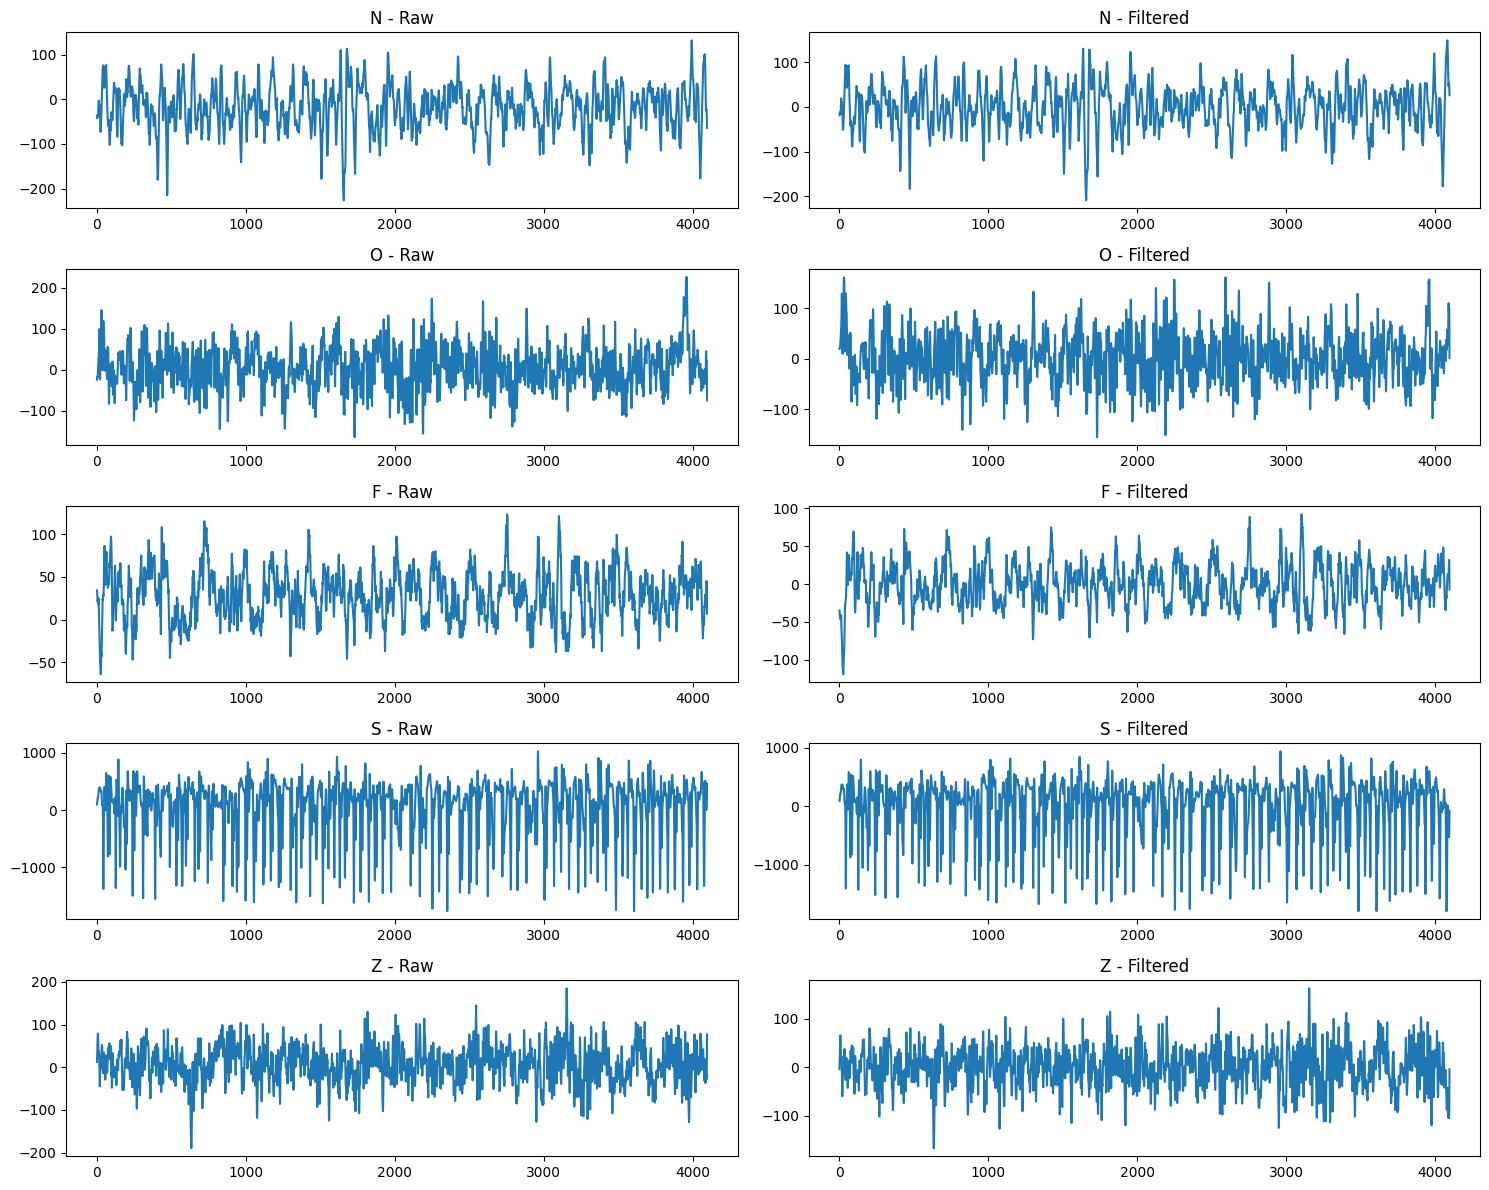

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,12))
for i, label in enumerate(folders):
    path = folders[label]
    file = sorted(os.listdir(path))[0]

    sig = np.loadtxt(os.path.join(path, file))
    filt = bandpass(sig)

    # Raw
    plt.subplot(5,2,2*i+1)
    plt.plot(sig)
    plt.title(f"{label} - Raw")

    # Filtered
    plt.subplot(5,2,2*i+2)
    plt.plot(filt)
    plt.title(f"{label} - Filtered")

plt.tight_layout()
plt.show()

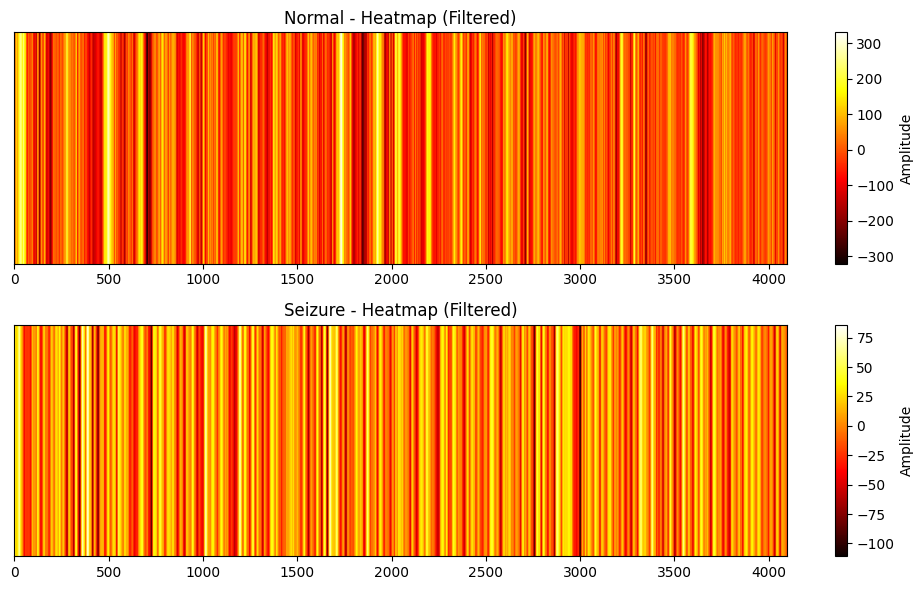

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
normal_idx = np.where(labels == 0)[0][0]
seizure_idx = np.where(labels == 1)[0][0]
signals_to_plot = {
    "Normal": filtered_data[normal_idx],
    "Seizure": filtered_data[seizure_idx]
}

for i, (name, sig) in enumerate(signals_to_plot.items()):

    sig = np.array(sig, dtype=float)
    plt.subplot(2,1,i+1)

    heat = np.reshape(sig, (1, -1))

    plt.imshow(heat, cmap='hot', aspect='auto')
    plt.title(f"{name} - Heatmap (Filtered)")
    plt.yticks([])
    plt.colorbar(label='Amplitude')

plt.tight_layout()
plt.show()

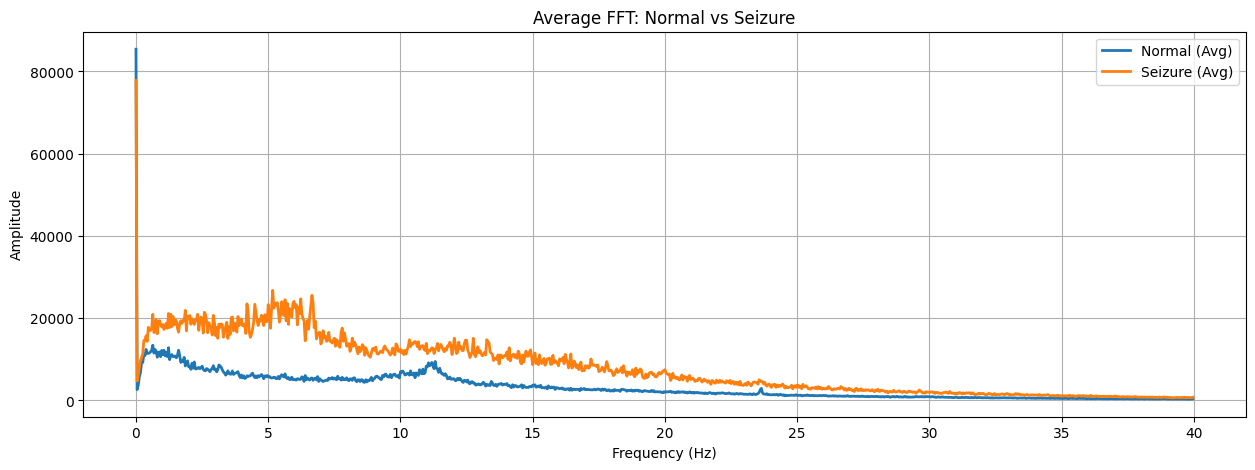

In [ ]:
#FFT
import numpy as np
import matplotlib.pyplot as plt
fs = 173.61  # sampling rate

#  1) FFT Function
def compute_fft(signal):
    signal = np.array(signal, dtype=float)
    n = len(signal)
    freq = np.fft.rfftfreq(n, d=1/fs)
    fft_values = np.abs(np.fft.rfft(signal))

    # نركز بس على 0 → 40 Hz
    mask = freq <= 40
    return freq[mask], fft_values[mask]


#  2) Average FFT
def avg_fft(target_label):
    fft_list = []

    for sig, label in zip(data, labels):
        if label == target_label:   # 0 = Normal / 1 = Seizure
            sig = np.array(sig, dtype=float)
            f, fft_vals = compute_fft(sig)
            fft_list.append(fft_vals)

    if len(fft_list) == 0:
        print("⚠️ Warning: No signals found for label:", target_label)
        return np.zeros_like(f)

    return np.mean(fft_list, axis=0)


# 3) حساب FFT
freq, _ = compute_fft(data[0])
fft_normal_avg = avg_fft(0)   # Normal
fft_seizure_avg = avg_fft(1)  # Seizure


#  4) رسم
plt.figure(figsize=(15,5))

plt.plot(freq, fft_normal_avg, label="Normal (Avg)", linewidth=2)
plt.plot(freq, fft_seizure_avg, label="Seizure (Avg)", linewidth=2)

plt.title("Average FFT: Normal vs Seizure")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

## ML




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,# 80% train and 20% test
    stratify=labels,
    random_state=42 # التقسيم ثابت قي كل مرة مش عشوائي
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:
model = RandomForestClassifier(
    n_estimators=400, #No of trees
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=400,
                       random_state=42)

In [ ]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.73      0.47      0.58        40
           1       0.72      0.88      0.79        60

    accuracy                           0.72       100
   macro avg       0.72      0.68      0.68       100
weighted avg       0.72      0.72      0.70       100



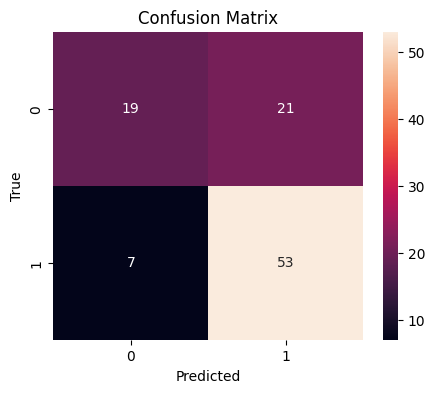

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import numpy as np
import IPython.display as ipd # مكتبة بتعرض الصوت

def play_alarm():
    fs = 44100
    t = np.linspace(0, 1, fs)
    tone = np.sin(2*np.pi*1000*t)
    ipd.display(ipd.Audio(tone, rate=fs, autoplay=True))

In [ ]:
def predict_signal(signal):
    signal = np.array(signal, dtype=float)

    feat = extract_features(signal)
    pred = model.predict([feat])[0]

    if pred == 1:
        print("⚠️ SEIZURE DETECTED!")
        play_alarm()
    else:
        print("Normal")

    return pred

In [ ]:
def test_file(path):
    signal = np.loadtxt(path, dtype=float)
    return predict_signal(signal)

In [ ]:
test_file("Dataset/F/F001.txt")

⚠️ SEIZURE DETECTED!


np.int64(1)

**GUI**

In [ ]:
import joblib
joblib.dump(model, "eeg_model.pkl")

['eeg_model.pkl']

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
from scipy.signal import butter, filtfilt
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
#  Settings
fs = 173.61

# Bandpass Filter
def bandpass(sig):
    sig = np.array(sig, dtype=float)
    nyq = 0.5 * fs
    b, a = butter(4, [0.5/nyq, 40/nyq], btype='band')
    return filtfilt(b, a, sig)

#  Features
def extract_features(sig):
    sig = np.array(sig, dtype=float)

    energy = np.sum(sig**2)
    fft_vals = np.abs(np.fft.rfft(sig))

    return [
        np.mean(sig),
        np.std(sig),
        np.sqrt(np.mean(sig**2)),
        np.log(energy + 1),
        np.mean(fft_vals),
        np.max(fft_vals)
    ]

#  Prediction
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_signal(file):
    signal = np.loadtxt(file.name)

    feat = extract_features(signal)

    feat = scaler.transform([feat])

    pred = model.predict(feat)[0]

    if pred == 1:
        return "⚠️ SEIZURE DETECTED"
    else:
        return "🟢 Normal"

In [ ]:
gr.Interface(
    fn=predict_signal,
    inputs=gr.File(label="Upload EEG Signal (.txt)"),
    outputs=gr.Textbox(label="Result"),
    title=" EEG Seizure Detection "
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://70b653718263e7ad68.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
